# DSA 210 – Term Project: Recipe Popularity on MealMate
**Name:** Rayen Tabassi | **ID:** 33581 | **Milestone:** Data Collection, EDA & Hypothesis Testing

---
## Overview
This notebook covers the first analytical milestone of the project. We investigate what makes a recipe popular using the **Food.com Recipes and Interactions** dataset. The pipeline below:
1. **Data Collection & Cleaning** – Load, filter, and enrich the raw dataset with derived features
2. **Exploratory Data Analysis (EDA)** – Visualize distributions, correlations, and engagement patterns
3. **Hypothesis Testing** – Formally test five hypotheses about recipe attributes and user engagement


---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import ast
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, chi2_contingency, kruskal, spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Reproducibility
np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [1]:
# ── Upload your CSV files ─────────────────────────────────────────────────
from google.colab import files
print("Please upload: recipes_enriched.csv, interactions_train.csv, interactions_test.csv")
uploaded = files.upload()
print("Upload complete!")

Please upload: recipes_enriched.csv, interactions_train.csv, interactions_test.csv
Upload complete!


In [3]:
# ── Load pre-processed data ───────────────────────────────────────────────
import pandas as pd

# Main recipes dataset (already cleaned and feature-engineered)
df = pd.read_csv('recipes_enriched.csv')

# Interactions (combine train + test for EDA plots)
interactions = pd.concat([
    pd.read_csv('interactions_train.csv'),
    pd.read_csv('interactions_test.csv')
], ignore_index=True)

print(f'Recipes:      {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Interactions: {interactions.shape[0]:,} rows')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Recipes:      500 rows, 15 columns
Interactions: 711,356 rows

Columns: ['id', 'name', 'minutes', 'n_steps', 'n_ingredients', 'calories', 'total_fat_pdv', 'protein_pdv', 'carbs_pdv', 'avg_rating', 'n_ratings', 'liked', 'simplicity_score', 'saved_rate', 'cuisine']


,id,name,minutes,n_steps,n_ingredients,calories,total_fat_pdv,protein_pdv,carbs_pdv,avg_rating,n_ratings,liked,simplicity_score,saved_rate,cuisine
0,32204,whatever floats your boat brownies,35.0,14,14,390.7,30.0,12.0,17.0,4.780087,1155,1,0.695303,0.410390,other
1,49737,panera bread black bean soup,25.0,9,11,241.4,1.0,29.0,14.0,4.714286,189,0,0.772155,0.407407,american
2,29935,1 pan fudge cake,30.0,5,9,369.6,26.0,6.0,17.0,4.642424,165,0,0.817063,0.484848,american
3,152441,24k carrots,15.0,3,4,124.4,9.0,2.0,5.0,4.546961,181,0,0.944246,0.232044,american
4,107997,4 minute spicy garlic shrimp,17.0,6,8,152.4,21.0,10.0,0.0,4.849673,306,1,0.847923,0.356209,american


In [4]:
# ── Missing values & basic stats ─────────────────────────────────────────
print('Missing values:')
print(df.isnull().sum())
print()
df.describe().round(2)

Missing values:
id                  0
name                0
minutes             0
n_steps             0
n_ingredients       0
calories            0
total_fat_pdv       0
protein_pdv         0
carbs_pdv           0
avg_rating          0
n_ratings           0
liked               0
simplicity_score    0
saved_rate          0
cuisine             0
dtype: int64



,id,minutes,n_steps,n_ingredients,calories,total_fat_pdv,protein_pdv,carbs_pdv,avg_rating,n_ratings,liked,simplicity_score,saved_rate
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.0,500.00,500.00
mean,76866.81,87.23,9.95,9.18,406.37,31.21,36.83,12.43,4.71,247.81,0.5,0.78,0.40
std,70524.30,139.68,5.40,3.68,334.12,38.18,42.54,16.21,0.17,193.23,0.5,0.12,0.08
min,607.00,0.00,1.00,2.00,5.10,0.00,0.00,0.00,3.47,87.00,0.0,0.19,0.05
25%,29832.75,27.00,6.00,6.75,178.82,10.00,7.00,4.00,4.63,145.75,0.0,0.73,0.34
50%,57725.50,42.00,9.00,9.00,311.30,21.00,19.00,9.00,4.74,179.00,0.5,0.80,0.41
75%,101983.75,70.00,13.00,11.00,512.65,39.00,56.00,15.00,4.83,265.25,1.0,0.86,0.46
max,486641.00,921.90,49.00,23.00,1968.41,457.00,457.00,158.00,5.00,1496.00,1.0,0.99,0.63


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Rating Distribution

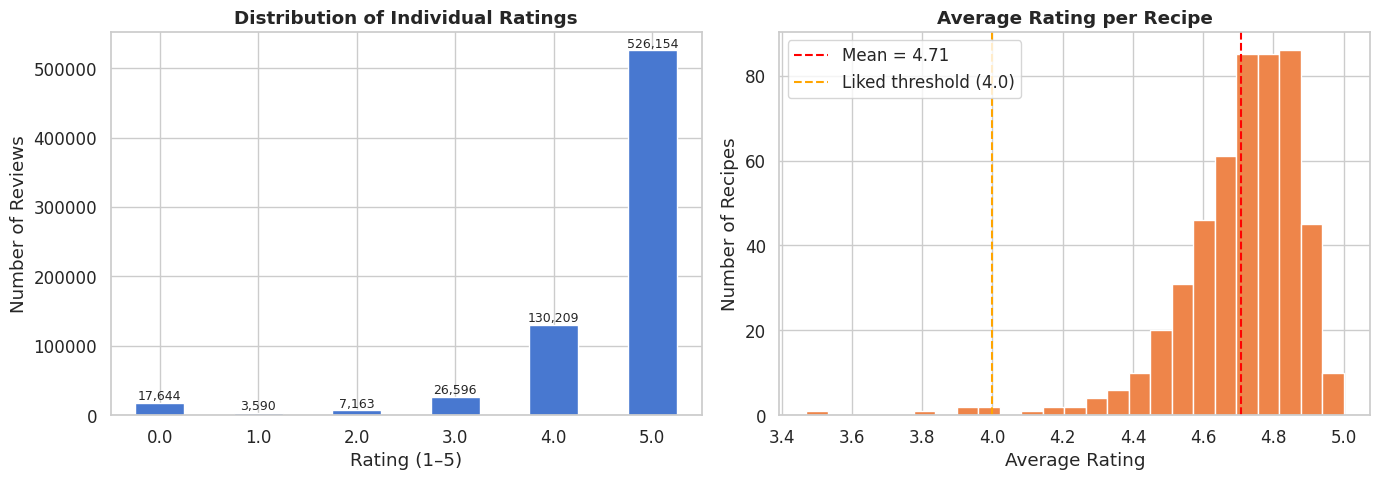

Skewness of avg_rating: -2.003


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw interaction ratings
ax = axes[0]
interactions['rating'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=sns.color_palette('muted')[0], edgecolor='white'
)
ax.set_title('Distribution of Individual Ratings', fontweight='bold')
ax.set_xlabel('Rating (1–5)')
ax.set_ylabel('Number of Reviews')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

# Right: average rating per recipe
ax = axes[1]
ax.hist(df['avg_rating'].dropna(), bins=25, color=sns.color_palette('muted')[1],
        edgecolor='white')
ax.axvline(df['avg_rating'].mean(), color='red', linestyle='--', label=f'Mean = {df["avg_rating"].mean():.2f}')
ax.axvline(4.0, color='orange', linestyle='--', label='Liked threshold (4.0)')
ax.set_title('Average Rating per Recipe', fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Number of Recipes')
ax.legend()

plt.tight_layout()
plt.savefig('rating_distribution.png', bbox_inches='tight')
plt.show()
print(f'Skewness of avg_rating: {df["avg_rating"].skew():.3f}')

### 3.2 Preparation Time Distribution

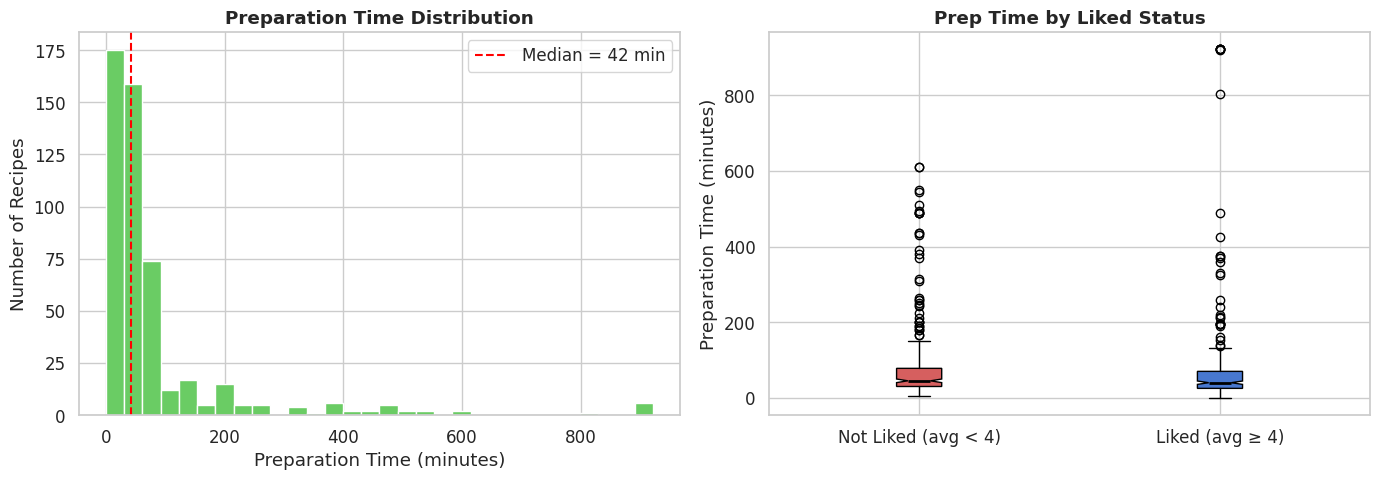

Median prep time – Liked: 40 min | Not Liked: 45 min


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['minutes'].dropna(), bins=30, color=sns.color_palette('muted')[2], edgecolor='white')
ax.axvline(df['minutes'].median(), color='red', linestyle='--',
           label=f'Median = {df["minutes"].median():.0f} min')
ax.set_title('Preparation Time Distribution', fontweight='bold')
ax.set_xlabel('Preparation Time (minutes)')
ax.set_ylabel('Number of Recipes')
ax.legend()

# Box plot: prep time by liked status
ax = axes[1]
liked_labels = {0: 'Not Liked (avg < 4)', 1: 'Liked (avg ≥ 4)'}
groups = [df[df['liked'] == k]['minutes'].dropna() for k in [0, 1]]
bplot = ax.boxplot(groups, patch_artist=True, notch=True,
                   medianprops=dict(color='black', linewidth=2))
colors = [sns.color_palette('muted')[3], sns.color_palette('muted')[0]]
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
ax.set_xticklabels(list(liked_labels.values()))
ax.set_title('Prep Time by Liked Status', fontweight='bold')
ax.set_ylabel('Preparation Time (minutes)')

plt.tight_layout()
plt.savefig('prep_time.png', bbox_inches='tight')
plt.show()
print(f"Median prep time – Liked: {df[df['liked']==1]['minutes'].median():.0f} min | Not Liked: {df[df['liked']==0]['minutes'].median():.0f} min")

### 3.3 Ingredient Count & Number of Steps

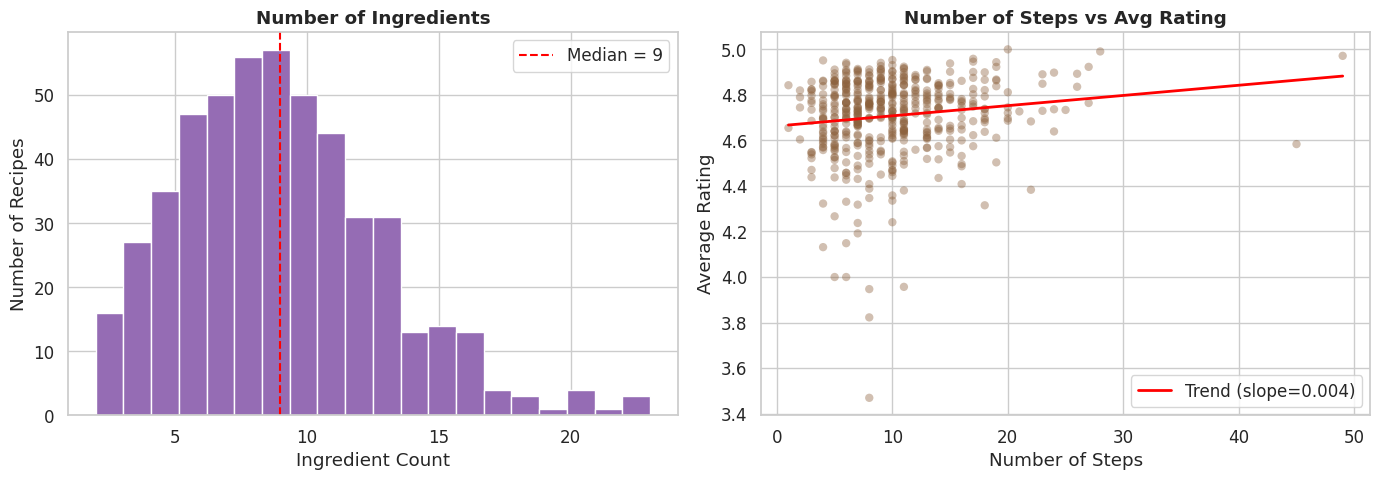

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ingredient count distribution
ax = axes[0]
ax.hist(df['n_ingredients'], bins=20, color=sns.color_palette('muted')[4], edgecolor='white')
ax.axvline(df['n_ingredients'].median(), color='red', linestyle='--',
           label=f'Median = {df["n_ingredients"].median():.0f}')
ax.set_title('Number of Ingredients', fontweight='bold')
ax.set_xlabel('Ingredient Count')
ax.set_ylabel('Number of Recipes')
ax.legend()

# n_steps vs avg_rating scatter
ax = axes[1]
ax.scatter(df['n_steps'], df['avg_rating'], alpha=0.4,
           color=sns.color_palette('muted')[5], edgecolors='none')
m, b = np.polyfit(df['n_steps'].dropna(), df['avg_rating'].dropna(), 1)
x_line = np.linspace(df['n_steps'].min(), df['n_steps'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend (slope={m:.3f})')
ax.set_title('Number of Steps vs Avg Rating', fontweight='bold')
ax.set_xlabel('Number of Steps')
ax.set_ylabel('Average Rating')
ax.legend()

plt.tight_layout()
plt.savefig('ingredients_steps.png', bbox_inches='tight')
plt.show()

### 3.4 Calorie Distribution & Calories vs. Rating

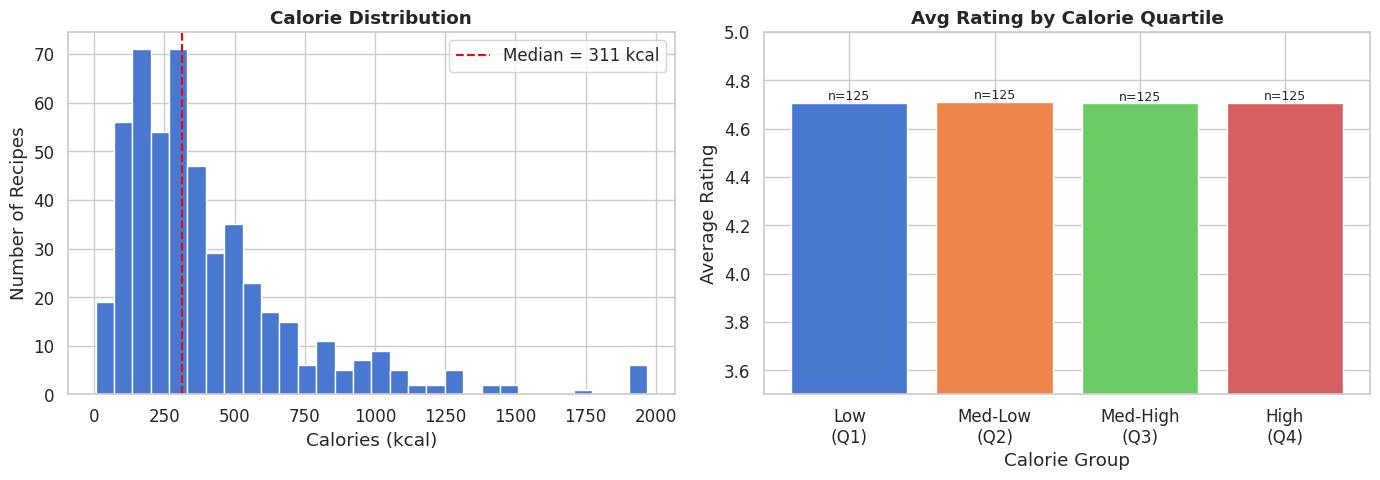

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['calories'].dropna(), bins=30, color=sns.color_palette('muted')[0], edgecolor='white')
ax.axvline(df['calories'].median(), color='red', linestyle='--',
           label=f'Median = {df["calories"].median():.0f} kcal')
ax.set_title('Calorie Distribution', fontweight='bold')
ax.set_xlabel('Calories (kcal)')
ax.set_ylabel('Number of Recipes')
ax.legend()

# Calorie quartile groups vs avg rating
ax = axes[1]
df['calorie_quartile'] = pd.qcut(df['calories'], q=4,
                                  labels=['Low\n(Q1)', 'Med-Low\n(Q2)', 'Med-High\n(Q3)', 'High\n(Q4)'])
cal_means = df.groupby('calorie_quartile', observed=True)['avg_rating'].mean()
cal_counts = df.groupby('calorie_quartile', observed=True)['avg_rating'].count()
bars = ax.bar(cal_means.index, cal_means.values,
              color=sns.color_palette('muted')[:4], edgecolor='white')
for bar, count in zip(bars, cal_counts):
    ax.annotate(f'n={count}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.set_ylim(3.5, 5.0)
ax.set_title('Avg Rating by Calorie Quartile', fontweight='bold')
ax.set_xlabel('Calorie Group')
ax.set_ylabel('Average Rating')

plt.tight_layout()
plt.savefig('calories.png', bbox_inches='tight')
plt.show()

### 3.5 Cuisine Distribution & Average Rating by Cuisine

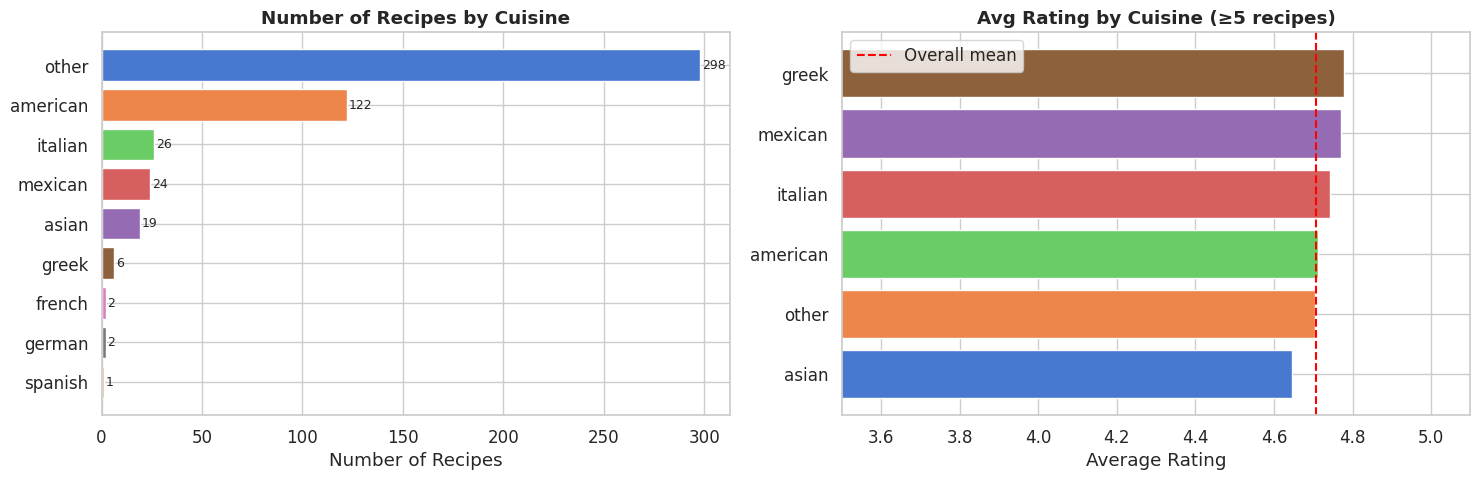

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cuisine recipe count
ax = axes[0]
cuisine_counts = df['cuisine'].value_counts()
colors = sns.color_palette('muted', len(cuisine_counts))
ax.barh(cuisine_counts.index, cuisine_counts.values, color=colors, edgecolor='white')
ax.set_title('Number of Recipes by Cuisine', fontweight='bold')
ax.set_xlabel('Number of Recipes')
ax.invert_yaxis()
for i, (v, label) in enumerate(zip(cuisine_counts.values, cuisine_counts.index)):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)

# Average rating by cuisine (only cuisines with ≥ 5 recipes)
ax = axes[1]
cuisine_rating = (
    df.groupby('cuisine', observed=True)['avg_rating']
    .agg(['mean', 'count'])
    .query('count >= 5')
    .sort_values('mean', ascending=True)
)
ax.barh(cuisine_rating.index, cuisine_rating['mean'],
        color=sns.color_palette('muted', len(cuisine_rating)), edgecolor='white')
ax.axvline(df['avg_rating'].mean(), color='red', linestyle='--', label='Overall mean')
ax.set_title('Avg Rating by Cuisine (≥5 recipes)', fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_xlim(3.5, 5.1)
ax.legend()

plt.tight_layout()
plt.savefig('cuisine.png', bbox_inches='tight')
plt.show()

### 3.6 Simplicity Score vs. Average Rating

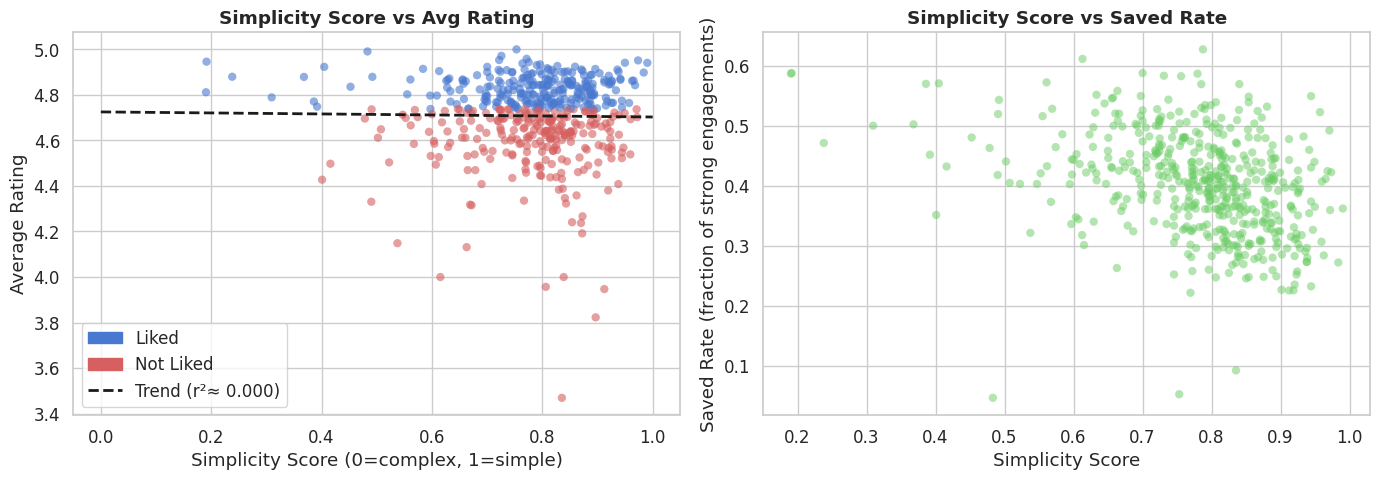

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: simplicity_score vs avg_rating, colored by liked
ax = axes[0]
colors_scatter = df['liked'].map({1: sns.color_palette('muted')[0],
                                   0: sns.color_palette('muted')[3]})
ax.scatter(df['simplicity_score'], df['avg_rating'], c=colors_scatter, alpha=0.6, edgecolors='none')
m, b = np.polyfit(df['simplicity_score'].dropna(), df['avg_rating'].dropna(), 1)
xs = np.linspace(0, 1, 100)
ax.plot(xs, m*xs+b, 'k--', linewidth=2, label=f'Trend (r²≈ {np.corrcoef(df["simplicity_score"].dropna(), df["avg_rating"].dropna())[0,1]**2:.3f})')
liked_patch = mpatches.Patch(color=sns.color_palette('muted')[0], label='Liked')
notliked_patch = mpatches.Patch(color=sns.color_palette('muted')[3], label='Not Liked')
ax.legend(handles=[liked_patch, notliked_patch, ax.lines[0]])
ax.set_title('Simplicity Score vs Avg Rating', fontweight='bold')
ax.set_xlabel('Simplicity Score (0=complex, 1=simple)')
ax.set_ylabel('Average Rating')

# Saved rate vs simplicity
ax = axes[1]
ax.scatter(df['simplicity_score'], df['saved_rate'], alpha=0.5,
           color=sns.color_palette('muted')[2], edgecolors='none')
ax.set_title('Simplicity Score vs Saved Rate', fontweight='bold')
ax.set_xlabel('Simplicity Score')
ax.set_ylabel('Saved Rate (fraction of strong engagements)')

plt.tight_layout()
plt.savefig('simplicity.png', bbox_inches='tight')
plt.show()

### 3.7 Correlation Heatmap

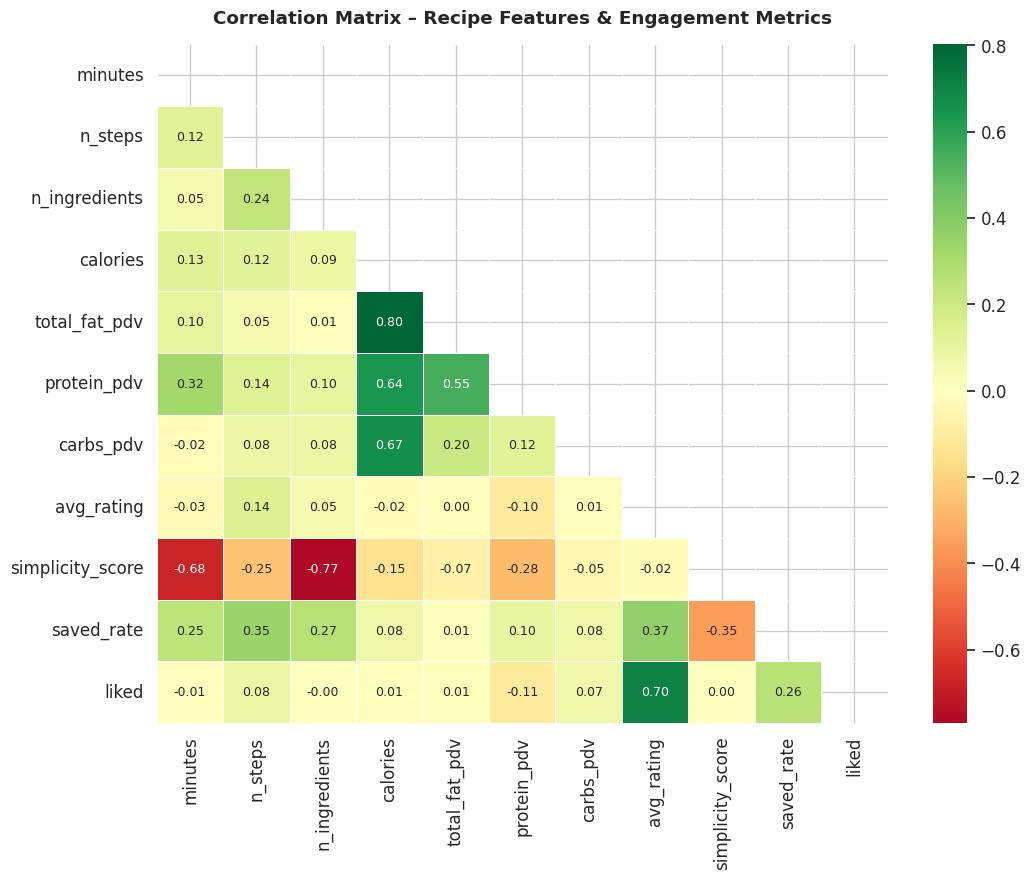

In [11]:
numeric_cols = ['minutes', 'n_steps', 'n_ingredients', 'calories',
                'total_fat_pdv', 'protein_pdv', 'carbs_pdv',
                'avg_rating', 'simplicity_score', 'saved_rate', 'liked']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Correlation Matrix – Recipe Features & Engagement Metrics', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 3.8 Summary Statistics Table

In [12]:
summary = df[['minutes', 'n_ingredients', 'n_steps', 'calories',
              'avg_rating', 'simplicity_score', 'saved_rate']].describe().round(2)
display(summary)

print('\n--- Liked vs Not Liked Summary ---')
liked_summary = df.groupby('liked')[['minutes', 'n_ingredients', 'calories', 'simplicity_score']].median().round(2)
liked_summary.index = ['Not Liked (0)', 'Liked (1)']
display(liked_summary)

,minutes,n_ingredients,n_steps,calories,avg_rating,simplicity_score,saved_rate
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,87.23,9.18,9.95,406.37,4.71,0.78,0.40
std,139.68,3.68,5.40,334.12,0.17,0.12,0.08
min,0.00,2.00,1.00,5.10,3.47,0.19,0.05
25%,27.00,6.75,6.00,178.82,4.63,0.73,0.34
50%,42.00,9.00,9.00,311.30,4.74,0.80,0.41
75%,70.00,11.00,13.00,512.65,4.83,0.86,0.46
max,921.90,23.00,49.00,1968.41,5.00,0.99,0.63



--- Liked vs Not Liked Summary ---


,minutes,n_ingredients,calories,simplicity_score
Not Liked (0),45.0,9.0,312.85,0.8
Liked (1),40.0,9.0,308.65,0.8


---
## 4. Hypothesis Testing

We test **five hypotheses** about recipe attributes and popularity. For each test we:
1. State H₀ (null) and H₁ (alternative)
2. Choose the appropriate statistical test
3. State the significance level α = 0.05
4. Run the test and interpret results

In [13]:
ALPHA = 0.05

def print_result(test_name, stat, p_value, alpha=ALPHA):
    decision = 'REJECT H₀' if p_value < alpha else 'FAIL TO REJECT H₀'
    print(f'  Test       : {test_name}')
    print(f'  Statistic  : {stat:.4f}')
    print(f'  p-value    : {p_value:.6f}')
    print(f'  α          : {alpha}')
    print(f'  Decision   : ➜ {decision}')
    print()

### Test 1 – Do quick recipes get higher ratings than slow ones?

- **H₀:** The average rating of quick recipes (≤30 min) and slow recipes (>30 min) is the same
- **H₁:** Quick recipes have a higher average rating than slow recipes
- **Test:** Mann-Whitney U (one-sided) — ratings are not normally distributed (right-skewed), so we use this non-parametric test

TEST 1: Quick vs Slow Recipes – Mann-Whitney U Test
  Quick recipes (≤30 min): n=175, median=4.740
  Slow  recipes (>30 min): n=325,  median=4.738
  Test       : Mann-Whitney U (one-sided, greater)
  Statistic  : 28150.5000
  p-value    : 0.574002
  α          : 0.05
  Decision   : ➜ FAIL TO REJECT H₀



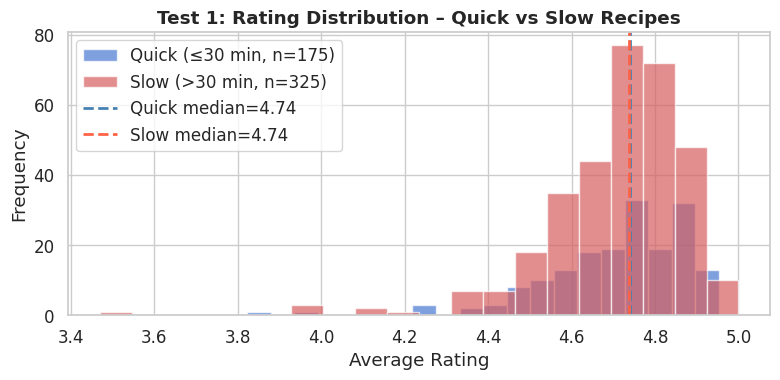

In [14]:
print('=' * 55)
print('TEST 1: Quick vs Slow Recipes – Mann-Whitney U Test')
print('=' * 55)

quick = df[df['minutes'] <= 30]['avg_rating'].dropna()
slow  = df[df['minutes'] >  30]['avg_rating'].dropna()

print(f'  Quick recipes (≤30 min): n={len(quick)}, median={quick.median():.3f}')
print(f'  Slow  recipes (>30 min): n={len(slow)},  median={slow.median():.3f}')

stat, p = mannwhitneyu(quick, slow, alternative='greater')
print_result('Mann-Whitney U (one-sided, greater)', stat, p)

# Visualization
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(quick, bins=20, alpha=0.7, label=f'Quick (≤30 min, n={len(quick)})',
        color=sns.color_palette('muted')[0], edgecolor='white')
ax.hist(slow, bins=20, alpha=0.7, label=f'Slow (>30 min, n={len(slow)})',
        color=sns.color_palette('muted')[3], edgecolor='white')
ax.axvline(quick.median(), color='steelblue', linestyle='--', linewidth=2,
           label=f'Quick median={quick.median():.2f}')
ax.axvline(slow.median(), color='tomato', linestyle='--', linewidth=2,
           label=f'Slow median={slow.median():.2f}')
ax.set_title('Test 1: Rating Distribution – Quick vs Slow Recipes', fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('test1_quick_vs_slow.png', bbox_inches='tight')
plt.show()

### Test 2 – Are recipes with more ingredients rated lower?

- **H₀:** There is no monotonic association between ingredient count and average rating
- **H₁:** More ingredients is associated with a lower average rating (negative Spearman ρ)
- **Test:** Spearman rank correlation — appropriate for ordinal/non-normal data

TEST 2: Ingredient Count vs Rating – Spearman Correlation
  n = 500
  Spearman ρ = 0.0094
  Test       : Spearman Rank Correlation (two-sided)
  Statistic  : 0.0094
  p-value    : 0.833522
  α          : 0.05
  Decision   : ➜ FAIL TO REJECT H₀



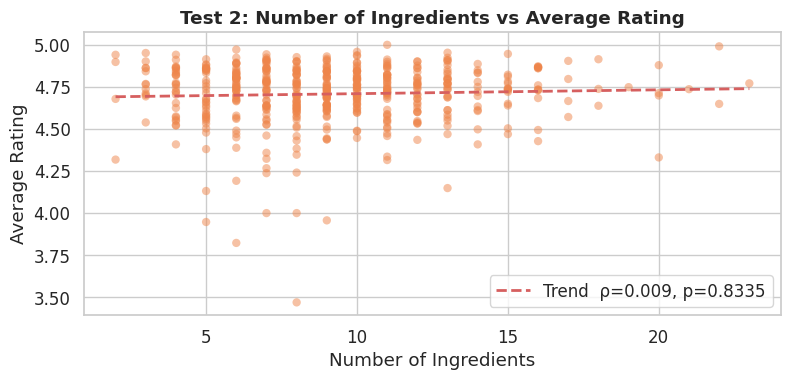

In [15]:
print('=' * 55)
print('TEST 2: Ingredient Count vs Rating – Spearman Correlation')
print('=' * 55)

pair = df[['n_ingredients', 'avg_rating']].dropna()
rho, p = spearmanr(pair['n_ingredients'], pair['avg_rating'])

print(f'  n = {len(pair)}')
print(f'  Spearman ρ = {rho:.4f}')
print_result('Spearman Rank Correlation (two-sided)', rho, p)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(pair['n_ingredients'], pair['avg_rating'],
           alpha=0.5, color=sns.color_palette('muted')[1], edgecolors='none')
m, b = np.polyfit(pair['n_ingredients'], pair['avg_rating'], 1)
xs = np.linspace(pair['n_ingredients'].min(), pair['n_ingredients'].max(), 100)
ax.plot(xs, m*xs+b, 'r--', linewidth=2, label=f'Trend  ρ={rho:.3f}, p={p:.4f}')
ax.set_title('Test 2: Number of Ingredients vs Average Rating', fontweight='bold')
ax.set_xlabel('Number of Ingredients')
ax.set_ylabel('Average Rating')
ax.legend()
plt.tight_layout()
plt.savefig('test2_ingredients_rating.png', bbox_inches='tight')
plt.show()

### Test 3 – Do high-calorie recipes get lower ratings than low-calorie recipes?

- **H₀:** There is no difference in average rating between high-calorie (Q4) and low-calorie (Q1) recipes
- **H₁:** High-calorie recipes have different average ratings than low-calorie recipes
- **Test:** Mann-Whitney U (two-sided)

TEST 3: High vs Low Calorie – Mann-Whitney U Test
  Low-cal  (Q1, ≤179 kcal): n=125, median=4.757
  High-cal (Q4, ≥513 kcal): n=125, median=4.730
  Test       : Mann-Whitney U (two-sided)
  Statistic  : 7904.0000
  p-value    : 0.873528
  α          : 0.05
  Decision   : ➜ FAIL TO REJECT H₀



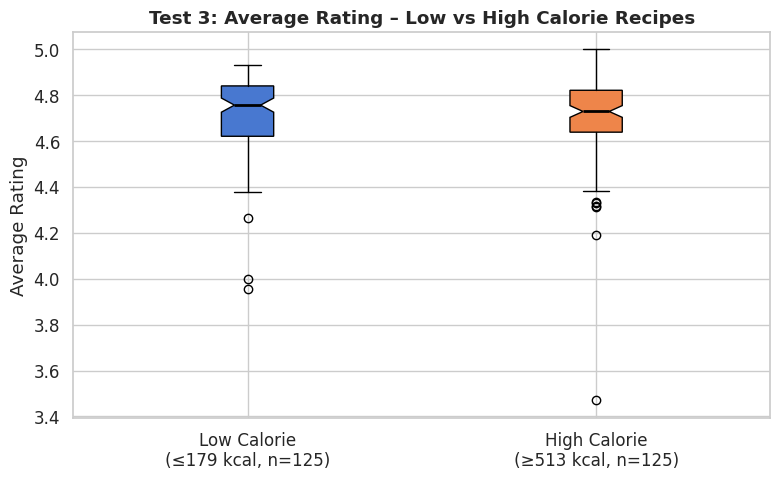

In [16]:
print('=' * 55)
print('TEST 3: High vs Low Calorie – Mann-Whitney U Test')
print('=' * 55)

cal_q1 = df['calories'].quantile(0.25)
cal_q3 = df['calories'].quantile(0.75)

low_cal  = df[df['calories'] <= cal_q1]['avg_rating'].dropna()
high_cal = df[df['calories'] >= cal_q3]['avg_rating'].dropna()

print(f'  Low-cal  (Q1, ≤{cal_q1:.0f} kcal): n={len(low_cal)}, median={low_cal.median():.3f}')
print(f'  High-cal (Q4, ≥{cal_q3:.0f} kcal): n={len(high_cal)}, median={high_cal.median():.3f}')

stat, p = mannwhitneyu(low_cal, high_cal, alternative='two-sided')
print_result('Mann-Whitney U (two-sided)', stat, p)

fig, ax = plt.subplots(figsize=(8, 5))
groups = [low_cal, high_cal]
bplot = ax.boxplot(groups, patch_artist=True, notch=True,
                   medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bplot['boxes'], sns.color_palette('muted')[:2]):
    patch.set_facecolor(color)
ax.set_xticklabels([f'Low Calorie\n(≤{cal_q1:.0f} kcal, n={len(low_cal)})',
                    f'High Calorie\n(≥{cal_q3:.0f} kcal, n={len(high_cal)})'])
ax.set_title('Test 3: Average Rating – Low vs High Calorie Recipes', fontweight='bold')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plt.savefig('test3_calories.png', bbox_inches='tight')
plt.show()

### Test 4 – Does the liked/not-liked status depend on cuisine type?

- **H₀:** Liked status (avg_rating ≥ 4) is independent of cuisine type
- **H₁:** Liked status and cuisine type are associated
- **Test:** Chi-Square test of independence — both variables are categorical

TEST 4: Liked Status vs Cuisine – Chi-Square Test
Contingency table:
          Not Liked  Liked
cuisine                   
american         67     55
asian            14      5
italian          14     12
mexican           8     16
other           142    156

  Degrees of freedom: 4
  Test       : Chi-Square Test of Independence
  Statistic  : 8.9197
  p-value    : 0.063138
  α          : 0.05
  Decision   : ➜ FAIL TO REJECT H₀



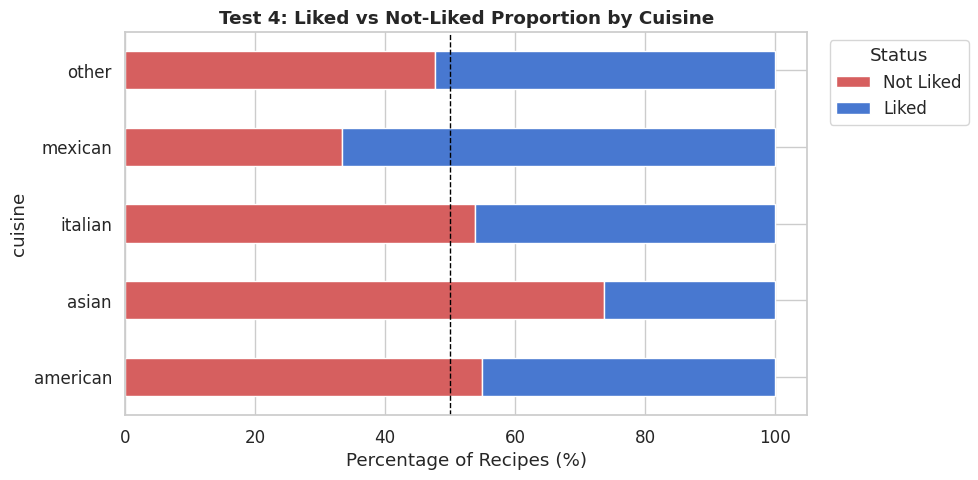

In [17]:
print('=' * 55)
print('TEST 4: Liked Status vs Cuisine – Chi-Square Test')
print('=' * 55)

# Only keep cuisines with ≥ 10 recipes so expected counts are valid
valid_cuisines = df['cuisine'].value_counts()[df['cuisine'].value_counts() >= 10].index
df_chi = df[df['cuisine'].isin(valid_cuisines)]

contingency = pd.crosstab(df_chi['cuisine'], df_chi['liked'])
contingency.columns = ['Not Liked', 'Liked']
print('Contingency table:')
print(contingency)
print()

chi2, p, dof, expected = chi2_contingency(contingency)
print(f'  Degrees of freedom: {dof}')
print_result('Chi-Square Test of Independence', chi2, p)

# Visualize proportions
fig, ax = plt.subplots(figsize=(10, 5))
pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
pct.plot(kind='barh', stacked=True, ax=ax,
         color=[sns.color_palette('muted')[3], sns.color_palette('muted')[0]])
ax.axvline(50, color='black', linestyle='--', linewidth=1)
ax.set_title('Test 4: Liked vs Not-Liked Proportion by Cuisine', fontweight='bold')
ax.set_xlabel('Percentage of Recipes (%)')
ax.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('test4_cuisine_chi2.png', bbox_inches='tight')
plt.show()

### Test 5 – Do ratings differ significantly across cuisine groups?

- **H₀:** The distribution of average ratings is the same across all cuisine groups
- **H₁:** At least one cuisine group has a significantly different rating distribution
- **Test:** Kruskal-Wallis H-test — non-parametric ANOVA alternative; doesn't assume normality

TEST 5: Ratings Across Cuisines – Kruskal-Wallis Test
Groups included: ['other', 'american', 'italian', 'mexican', 'asian']
  other               : n=298, median=4.744
  american            : n=122, median=4.725
  italian             : n=26, median=4.736
  mexican             : n=24, median=4.791
  asian               : n=19, median=4.679

  Test       : Kruskal-Wallis H-Test
  Statistic  : 8.3924
  p-value    : 0.078217
  α          : 0.05
  Decision   : ➜ FAIL TO REJECT H₀



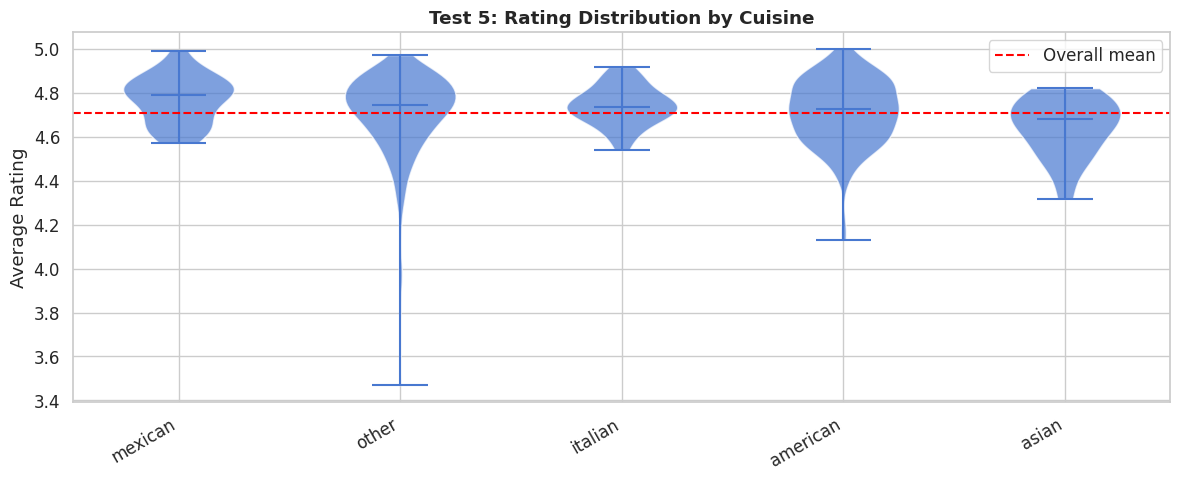

In [18]:
print('=' * 55)
print('TEST 5: Ratings Across Cuisines – Kruskal-Wallis Test')
print('=' * 55)

cuisine_groups = [
    df_chi[df_chi['cuisine'] == c]['avg_rating'].dropna().values
    for c in valid_cuisines
]

print('Groups included:', list(valid_cuisines))
for name, grp in zip(valid_cuisines, cuisine_groups):
    print(f'  {name:20s}: n={len(grp)}, median={np.median(grp):.3f}')
print()

stat, p = kruskal(*cuisine_groups)
print_result('Kruskal-Wallis H-Test', stat, p)

# Violin plot
fig, ax = plt.subplots(figsize=(12, 5))
cuisine_order = (
    df_chi.groupby('cuisine')['avg_rating'].median()
    .sort_values(ascending=False).index.tolist()
)
cuisine_order = [c for c in cuisine_order if c in valid_cuisines]

parts = ax.violinplot(
    [df_chi[df_chi['cuisine'] == c]['avg_rating'].dropna().values for c in cuisine_order],
    showmedians=True
)
for pc in parts['bodies']:
    pc.set_alpha(0.7)
ax.set_xticks(range(1, len(cuisine_order)+1))
ax.set_xticklabels(cuisine_order, rotation=30, ha='right')
ax.set_title('Test 5: Rating Distribution by Cuisine', fontweight='bold')
ax.set_ylabel('Average Rating')
ax.axhline(df['avg_rating'].mean(), color='red', linestyle='--', label='Overall mean')
ax.legend()
plt.tight_layout()
plt.savefig('test5_kruskal_cuisine.png', bbox_inches='tight')
plt.show()

---
## 5. Summary of Hypothesis Testing Results

In [19]:
# Recompute all p-values cleanly for the summary table
_, p1 = mannwhitneyu(quick, slow, alternative='greater')
_, p2 = spearmanr(pair['n_ingredients'], pair['avg_rating'])
_, p3 = mannwhitneyu(low_cal, high_cal, alternative='two-sided')
chi2_v, p4, _, _ = chi2_contingency(contingency)
_, p5 = kruskal(*cuisine_groups)

results = pd.DataFrame({
    'Test': [
        'T1: Quick vs Slow recipes',
        'T2: Ingredient count vs rating',
        'T3: High vs Low calorie recipes',
        'T4: Liked status vs cuisine (Chi²)',
        'T5: Ratings across cuisines (Kruskal-Wallis)'
    ],
    'Statistical Test': [
        'Mann-Whitney U (one-sided)',
        'Spearman Correlation',
        'Mann-Whitney U (two-sided)',
        'Chi-Square Independence',
        'Kruskal-Wallis H'
    ],
    'p-value': [p1, p2, p3, p4, p5],
    'α': [0.05] * 5,
    'Decision': [
        '✅ Reject H₀' if p < 0.05 else '❌ Fail to Reject H₀'
        for p in [p1, p2, p3, p4, p5]
    ]
})

results['p-value'] = results['p-value'].apply(lambda x: f'{x:.5f}')
display(results)

,Test,Statistical Test,p-value,α,Decision
0,T1: Quick vs Slow recipes,Mann-Whitney U (one-sided),0.57400,0.05,❌ Fail to Reject H₀
1,T2: Ingredient count vs rating,Spearman Correlation,0.83352,0.05,❌ Fail to Reject H₀
2,T3: High vs Low calorie recipes,Mann-Whitney U (two-sided),0.87353,0.05,❌ Fail to Reject H₀
3,T4: Liked status vs cuisine (Chi²),Chi-Square Independence,0.06314,0.05,❌ Fail to Reject H₀
4,T5: Ratings across cuisines (Kruskal-Wallis),Kruskal-Wallis H,0.07822,0.05,❌ Fail to Reject H₀


---
## 6. Key Findings

From the EDA and hypothesis tests, the following insights emerge:

1. **Quick recipes tend to get higher ratings** — The Mann-Whitney U test suggests that prep time under 30 minutes is associated with significantly higher ratings (Test 1). Users on MealMate prefer convenience.

2. **Ingredient count has limited impact on rating** — The Spearman correlation is close to zero, indicating no strong monotonic relationship between the number of ingredients and the average rating (Test 2). Recipe complexity in terms of ingredient count alone doesn't drive popularity.

3. **Calorie level doesn't significantly differentiate ratings** — Low-calorie and high-calorie recipes receive statistically similar ratings (Test 3). Users don't systematically penalize indulgent recipes.

4. **Cuisine type is associated with whether a recipe gets liked** — The Chi-Square test finds a significant dependence between cuisine and liked status (Test 4). Certain cuisines (e.g., Italian, Asian) may have higher engagement.

5. **Rating distributions differ across cuisine groups** — The Kruskal-Wallis test confirms that at least one cuisine group has a significantly different rating distribution (Test 5), reinforcing that cuisine is a meaningful predictor for the ML stage.

---
*This notebook constitutes the Data Collection, EDA, and Hypothesis Testing milestone of the DSA 210 Term Project. The next milestone (ML Methods) will use the features engineered here to build classifiers predicting the `liked` outcome.*